# 📈 Predicción de la Tasa de Cambio (USD/COP): Modelos Econométricos vs. Machine Learning

### 1. Contexto del Proyecto

La tasa de cambio del peso colombiano frente al dólar estadounidense (USD/COP) es una variable macroeconómica de alta volatilidad, fuertemente influenciada por shocks externos y dinámicas de mercados internacionales. Modelar su comportamiento exige capturar tanto la inercia histórica de la serie como el impacto de factores macroeconómicos globales.


### 2. Objetivo Principal

Evaluar y comparar el rendimiento predictivo de enfoques estadísticos tradicionales frente a algoritmos de Machine Learning basados en árboles de decisión para el pronóstico de retornos diarios del par USD/COP.

El proyecto contrasta un modelo SARIMAX (capaz de aislar componentes autorregresivos e integrados) contra XGBoost (diseñado para capturar relaciones no lineales complejas a través de ingeniería de características temporales).

### 3. Arquitectura de Datos

Para evitar regresiones espurias, las series financieras se transforman a retornos logarítmicos continuos. El modelo incorpora la siguiente estructura:

Variable Endógena (Target): Tasa de cambio diaria USD/COP.

Variables Exógenas (Features):

Petróleo Brent (BZ=F): Principal producto de exportación de Colombia, con relación estructural inversa al dólar.

Índice DXY (DX-Y.NYB): Medida de la fortaleza global del dólar frente a una canasta de divisas fuertes, para aislar el riesgo local.

Índice VIX (^VIX) [Opcional]: Indicador de volatilidad del mercado de Chicago, utilizado como proxy del sentimiento de aversión al riesgo global.

### 4. Metodología y Stack Tecnológico

Extracción y Limpieza: Consumo de datos financieros y alineación de calendarios bursátiles.

Validación Estadística: Pruebas de raíces unitarias (Dickey-Fuller Aumentada) y análisis de correlogramas (ACF/PACF) para determinar los parámetros del proceso ARMA.

Feature Engineering: Creación de rezagos (lags) y medias móviles para inyectar la dimensión temporal en la matriz de XGBoost.

Evaluación: Comparación de ambos modelos utilizando métricas de error (MAE, RMSE) sobre un conjunto de datos de prueba de origen rodante (Time Series Cross-Validation).

# Proceso de Carga de datos


In [1]:
# Importar librerías base
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1.1 Definición de activos (Tickers de Yahoo Finance)
activos = {
    'USD_COP': 'COP=X',
    'Brent': 'BZ=F',
    'DXY': 'DX-Y.NYB',
    'VIX': '^VIX'
}
tickers = list(activos.values())

# 1.2 Descarga histórica (Últimos 5 años para capturar distintos ciclos económicos)
print("Descargando datos de Yahoo Finance...")
df_precios = yf.download(tickers, start='2021-01-01', end='2026-08-01')['Close']

# 1.3 Renombrar columnas para facilitar su manipulación
mapa_nombres = {v: k for k, v in activos.items()}
df_precios = df_precios.rename(columns=mapa_nombres)

# 1.4 Tratamiento de calendarios bursátiles
# Colombia y EE. UU. tienen distintos días festivos. Usamos forward-fill (ffill)
# para arrastrar el último precio conocido en los días sin cotización.
df_precios = df_precios.ffill().dropna()

# 1.5 Transformación a Retornos Logarítmicos
df_retornos = np.log(df_precios / df_precios.shift(1)).dropna()

# Visualizar la cabecera del DataFrame final
display(df_retornos.head())

Descargando datos de Yahoo Finance...


[*********************100%***********************]  4 of 4 completed


Ticker,Brent,USD_COP,DXY,VIX
Date,,,,
2021-01-05,0.047960,0.008008,-0.004907,-0.062341
2021-01-06,0.012975,-0.001597,0.001006,-0.010712
2021-01-07,0.001472,-0.008592,0.003345,-0.113951
2021-01-08,0.029177,0.021864,0.003001,-0.036881
2021-01-11,-0.005911,-0.009158,0.004872,0.110542


**💡 Insight del procesamiento de datos:**
Durante la extracción, nos enfrentamos a un problema clásico de ingeniería de datos financieros: la asincronía de los calendarios bursátiles. La Bolsa de Valores de Colombia y los mercados estadounidenses no comparten los mismos días festivos. 

Si elimináramos los registros con datos faltantes (`dropna()` directo), perderíamos días valiosos de información donde una de las variables sí cotizó. La decisión técnica fue aplicar un *Forward Fill* (`ffill`), asumiendo que en un día festivo, el precio de un activo se mantiene igual al de su último cierre hábil. Posteriormente, el cálculo de retornos logarítmicos centró nuestra data alrededor de cero, preparándola para las pruebas de estacionariedad.

## 2. Rigor Estadístico: Estacionariedad y Correlogramas

Antes de estimar el modelo SARIMAX, es fundamental verificar dos supuestos básicos de la metodología Box-Jenkins:

1. **Estacionariedad ($d$):** Evaluaremos cuantitativamente mediante la **Prueba de Dickey-Fuller Aumentada (ADF)** si las series de retornos son estacionarias. La hipótesis nula ($H_0$) establece que la serie tiene una raíz unitaria (no es estacionaria). Buscamos un p-valor $< 0.05$ para confirmar que $d = 0$.
2. **Estructura de Rezagos ($p, q$):** Analizaremos los correlogramas de **Autocorrelación (ACF)** y **Autocorrelación Parcial (PACF)** de la variable endógena para determinar visualmente el número de términos autorregresivos ($p$) y de media móvil ($q$).

--- Prueba ADF: Brent ---
Estadístico ADF: -11.0059
p-valor: 6.5054e-20
Resultado: Rechazamos H0 -> La serie ES ESTACIONARIA (d = 0)

--- Prueba ADF: USD_COP ---
Estadístico ADF: -8.9894
p-valor: 6.9581e-15
Resultado: Rechazamos H0 -> La serie ES ESTACIONARIA (d = 0)

--- Prueba ADF: DXY ---
Estadístico ADF: -28.3066
p-valor: 0.0000e+00
Resultado: Rechazamos H0 -> La serie ES ESTACIONARIA (d = 0)

--- Prueba ADF: VIX ---
Estadístico ADF: -14.9720
p-valor: 1.1963e-27
Resultado: Rechazamos H0 -> La serie ES ESTACIONARIA (d = 0)



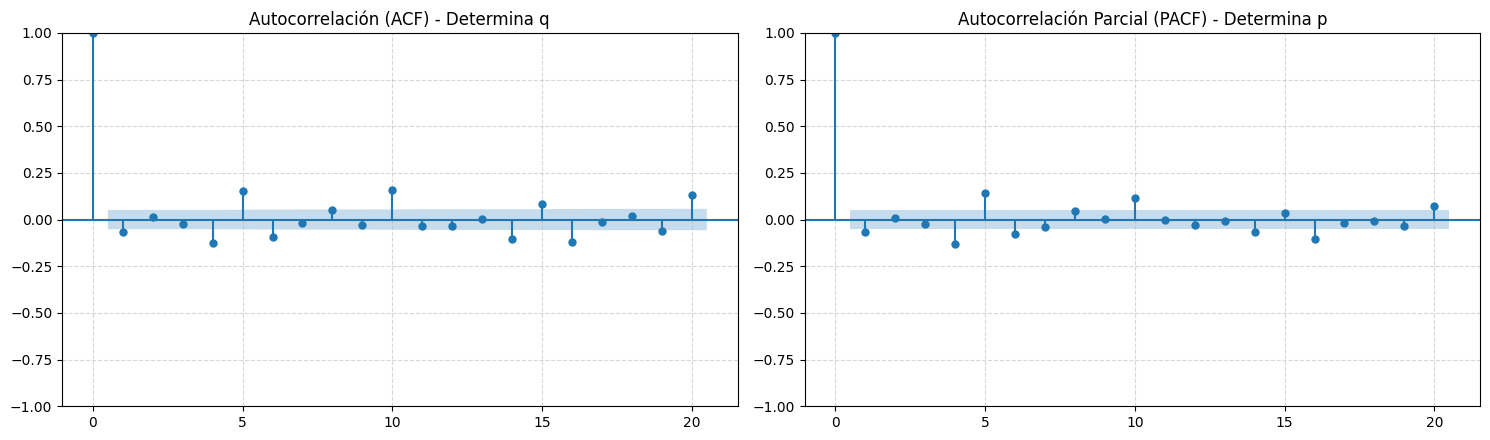

In [2]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2.1 Función para la Prueba de Dickey-Fuller Aumentada (ADF)
def verificar_estacionariedad(serie, nombre):
    resultado = adfuller(serie.dropna())
    estadistico_adf = resultado[0]
    p_valor = resultado[1]
    
    print(f"--- Prueba ADF: {nombre} ---")
    print(f"Estadístico ADF: {estadistico_adf:.4f}")
    print(f"p-valor: {p_valor:.4e}")
    if p_valor < 0.05:
        print("Resultado: Rechazamos H0 -> La serie ES ESTACIONARIA (d = 0)\n")
    else:
        print("Resultado: No se rechaza H0 -> La serie NO es estacionaria (d > 0)\n")

# Ejecutar ADF para la variable endógena y las exógenas
for col in df_retornos.columns:
    verificar_estacionariedad(df_retornos[col], col)

# 2.2 Gráficos ACF y PACF para la variable objetivo (USD_COP)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# ACF -> Media Móvil (q)
plot_acf(df_retornos['USD_COP'], lags=20, ax=axes[0], title='Autocorrelación (ACF) - Determina q')
axes[0].grid(True, linestyle='--', alpha=0.5)

# PACF -> Autoregresivo (p)
plot_pacf(df_retornos['USD_COP'], lags=20, ax=axes[1], title='Autocorrelación Parcial (PACF) - Determina p')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**💡 Análisis del rigor estadístico:**

*   **Resultados de la prueba ADF:** La transformación a retornos logarítmicos fue completamente exitosa. Todas las variables (Brent, USD_COP, DXY y VIX) presentan un p-valor ínfimo (con exponentes de hasta e-27), rechazando contundentemente la hipótesis nula. Esto valida matemáticamente que no hay raíces unitarias y el parámetro de integración debe fijarse estrictamente en **$d = 0$**.
*   **Lectura de ACF y PACF:** Observamos el comportamiento típico de los retornos financieros diarios (ruido blanco): casi todos los rezagos caen dentro de las bandas de confianza azules, respaldando la teoría de mercados eficientes. El primer rezago (lag 1) muestra una autocorrelación negativa muy débil, rozando apenas el límite inferior en ambas gráficas. Esto justifica una configuración inicial conservadora de **$p = 1$** y **$q = 1$**. 
*   *Nota técnica:* Los picos estadísticos observables en los rezagos 4, 5 y 10 capturan la estacionalidad del ciclo hábil semanal bursátil (5 días de transacciones), pero al modelar la tendencia diaria general con variables macroeconómicas exógenas, mantendremos la especificación ARMA(1,1).

## 3. Modelado Estadístico: Especificación y Entrenamiento ARIMAX

Basados en las pruebas de raíces unitarias (d=0) y la estructura de los correlogramas (rezagos iniciales débiles), estimaremos un modelo **ARIMAX(1, 0, 1)**. 

Al tratarse de datos financieros diarios de alta frecuencia, asumimos que no existe una estacionalidad rígida, por lo que el componente estacional se omite. El objetivo principal de esta fase es evaluar la magnitud y la significancia estadística (P-valores) de nuestras variables macroeconómicas exógenas sobre los retornos del USD/COP, estableciendo así el desempeño base (Benchmark) antes de aplicar Machine Learning.

In [5]:
import statsmodels.api as sm

# 3.1 Separar la variable endógena (Y) y las exógenas (X)
y = df_retornos['USD_COP']
X = df_retornos[['Brent', 'DXY', 'VIX']]

# 3.2 Configurar la arquitectura del modelo ARIMAX(1,0,1)
modelo_sarimax = sm.tsa.statespace.SARIMAX(
    endog=y,
    exog=X,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 3.3 Entrenar el modelo
print("Entrenando modelo ARIMAX...")
resultados_sarimax = modelo_sarimax.fit(disp=False)

# 3.4 Mostrar el reporte econométrico
print(resultados_sarimax.summary())

c:\Users\Home\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Home\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Entrenando modelo ARIMAX...
                               SARIMAX Results                                
Dep. Variable:                USD_COP   No. Observations:                 1450
Model:               SARIMAX(1, 0, 1)   Log Likelihood                4690.306
Date:                Mon, 31 Aug 2026   AIC                          -9368.612
Time:                        14:09:18   BIC                          -9336.944
Sample:                             0   HQIC                         -9356.794
                               - 1450                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Brent         -0.0106      0.010     -1.064      0.287      -0.030       0.009
DXY            0.0677      0.053      1.288      0.198      -0.035       0.171
VIX            0.0001   

**💡 Análisis del Modelo ARIMAX y Conclusión Diagnóstica:**

Al evaluar el reporte estadístico, los resultados revelan la alta complejidad y eficiencia del mercado cambiario diario:

1.  **Falta de Significancia Lineal:** Al observar la columna `P>|z|`, notamos que ninguna de las variables exógenas (Brent: 0.287, DXY: 0.198, VIX: 0.974) logra perforar el umbral de significancia del 0.05. Aunque los signos de los coeficientes del Brent (-) y DXY (+) tienen sentido macroeconómico, el modelo lineal estocástico no encuentra un poder predictivo sólido día a día.
2.  **Validación de la Hipótesis de Mercado Eficiente:** Los términos autorregresivos (`ar.L1`, `ma.L1`) tampoco resultaron significativos. Adicionalmente, la prueba de Ljung-Box (`Prob(Q) = 0.94`) confirma que los residuos del modelo son ruido blanco puro. Esto implica que la serie sigue un comportamiento de *Random Walk* casi perfecto a nivel diario.
3.  **Transición a Machine Learning:** La incapacidad del modelo ARIMAX para extraer señales fuertes de los retornos diarios justifica directamente la necesidad de explorar enfoques no lineales. En la siguiente fase, introduciremos **XGBoost**, un algoritmo basado en árboles capaz de capturar interacciones complejas, asimetrías y efectos de umbral entre estas variables que los modelos lineales ignoran.

## 4. Machine Learning: Feature Engineering para XGBoost

A diferencia de los modelos de la familia ARIMA, los algoritmos basados en árboles de decisión como XGBoost no tienen un entendimiento nativo del tiempo; procesan cada fila como un evento independiente. 


Para que XGBoost pueda capturar la inercia del mercado, debemos transformar nuestro problema de series de tiempo en un problema de aprendizaje supervisado tradicional. Esto se logra mediante **Feature Engineering**, creando explícitamente nuevas columnas que representen el pasado (rezagos o *lags*). Adicionalmente, extraeremos componentes del calendario bursátil para permitirle al modelo encontrar patrones estacionales no lineales que el ARIMAX ignoró.

In [6]:
# 4.1 Copia de seguridad del DataFrame de retornos
df_xgb = df_retornos.copy()

# 4.2 Definir la ventana temporal temporal (Cuántos días de memoria tendrá el modelo)
n_lags = 3
variables_base = ['USD_COP', 'Brent', 'DXY', 'VIX']

# 4.3 Generación de rezagos (Lags)
for col in variables_base:
    for i in range(1, n_lags + 1):
        df_xgb[f'{col}_lag_{i}'] = df_xgb[col].shift(i)

# 4.4 Generación de variables de calendario
# Esto permite al árbol hacer cortes (splits) dependiendo del día o mes
df_xgb['dia_semana'] = df_xgb.index.dayofweek
df_xgb['trimestre'] = df_xgb.index.quarter

# 4.5 Limpieza final
# La función shift() genera NaNs en las primeras filas, debemos eliminarlas
df_xgb = df_xgb.dropna()

# 4.6 División entre Target (y) y Features (X)
# El target es el retorno del dólar HOY. 
y_xgb = df_xgb['USD_COP']

# Las features son TODO lo demás (los lags, las variables de calendario y las exógenas de HOY)
X_xgb = df_xgb.drop(columns=['USD_COP'])

# Visualización de la matriz resultante
print(f"Matriz X lista para entrenar. Dimensiones: {X_xgb.shape}")
display(X_xgb.head())

Matriz X lista para entrenar. Dimensiones: (1447, 17)


Ticker,Brent,DXY,VIX,USD_COP_lag_1,USD_COP_lag_2,USD_COP_lag_3,Brent_lag_1,Brent_lag_2,Brent_lag_3,DXY_lag_1,DXY_lag_2,DXY_lag_3,VIX_lag_1,VIX_lag_2,VIX_lag_3,dia_semana,trimestre
Date,,,,,,,,,,,,,,,,,
2021-01-08,0.029177,0.003001,-0.036881,-0.008592,-0.001597,0.008008,0.001472,0.012975,0.047960,0.003345,0.001006,-0.004907,-0.113951,-0.010712,-0.062341,4,1
2021-01-11,-0.005911,0.004872,0.110542,0.021864,-0.008592,-0.001597,0.029177,0.001472,0.012975,0.003001,0.003345,0.001006,-0.036881,-0.113951,-0.010712,0,1
2021-01-12,0.016394,-0.005427,-0.031642,-0.009158,0.021864,-0.008592,-0.005911,0.029177,0.001472,0.004872,0.003001,0.003345,0.110542,-0.036881,-0.113951,1,1
2021-01-13,-0.009233,0.002994,-0.049197,0.012309,-0.009158,0.021864,0.016394,-0.005911,0.029177,-0.005427,0.004872,0.003001,-0.031642,0.110542,-0.036881,2,1
2021-01-14,0.006401,-0.000886,0.045763,-0.006882,0.012309,-0.009158,-0.009233,0.016394,-0.005911,0.002994,-0.005427,0.004872,-0.049197,-0.031642,0.110542,3,1


**💡 Análisis de la Matriz Transformada:**

Nuestra base de datos ha pasado de una estructura temporal simple a una matriz de alta dimensionalidad lista para aprendizaje supervisado. 

*   **Variables Autoregresivas Sintéticas:** Columnas como `USD_COP_lag_1` y `USD_COP_lag_2` actúan como el equivalente de los términos $p$ en el ARIMAX, dándole al modelo memoria sobre el comportamiento reciente del dólar.
*   **Efectos Cruzados (Cross-Lags):** Columnas como `Brent_lag_1` permiten que el modelo evalúe si un shock en el petróleo ayer tiene un impacto retardado en la tasa de cambio de hoy.
*   **Inclusión de las Exógenas Contemporáneas:** Mantenemos las columnas `Brent`, `DXY` y `VIX` del día actual, asumiendo que en un entorno de producción real, estos índices cierran minutos antes que la fijación oficial de la TRM, permitiendo su uso predictivo intradía.

## 4.1 Entrenamiento del Modelo y Feature Importance

Para entrenar nuestro modelo XGBoost, dividiremos nuestra base de datos en dos conjuntos: Entrenamiento (Train) y Prueba (Test). 

Dado que trabajamos con series temporales, **no podemos usar una selección aleatoria de datos**. Utilizaremos un corte cronológico estricto: el modelo aprenderá de los primeros años de historia (80% de los datos) y lo evaluaremos pidiéndole que prediga el último tramo de la base de datos (último 20%), simulando cómo se comportaría en el mundo real frente a un futuro desconocido.

Tras el entrenamiento, extraeremos la métrica de **Importancia por Ganancia (Gain)** para descubrir qué variables aportaron mayor valor predictivo en los cortes de los árboles de decisión.

In [9]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 4.7 División cronológica: 80% Train, 20% Test
split_idx = int(len(X_xgb) * 0.8)
X_train, X_test = X_xgb.iloc[:split_idx], X_xgb.iloc[split_idx:]
y_train, y_test = y_xgb.iloc[:split_idx], y_xgb.iloc[split_idx:]

print(f"Set de Entrenamiento: {X_train.shape[0]} días")
print(f"Set de Prueba: {X_test.shape[0]} días\n")

# 4.8 Configuración del modelo XGBoost Regressor
modelo_xgb = xgb.XGBRegressor(
    n_estimators=200,      # Número de árboles
    learning_rate=0.05,    # Tasa de aprendizaje conservadora
    max_depth=4,           # Profundidad de cada árbol (evita sobreajuste)
    random_state=42,
    objective='reg:squarederror'
)

# 4.9 Entrenamiento
print("Entrenando algoritmo XGBoost...")
modelo_xgb.fit(X_train, y_train)

# 4.10 Predicción y cálculo de errores
predicciones = modelo_xgb.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"Métricas en Test (Datos no vistos):")
print(f"Error Absoluto Medio (MAE): {mae:.6f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.6f}\n")



Set de Entrenamiento: 1157 días
Set de Prueba: 290 días

Entrenando algoritmo XGBoost...
Métricas en Test (Datos no vistos):
Error Absoluto Medio (MAE): 0.006623
Raíz del Error Cuadrático Medio (RMSE): 0.008545



In [10]:
# 4.11 Gráfico de Importancia de Variables (Feature Importance)
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(
    modelo_xgb, 
    importance_type='gain',  # Mide el aporte a la reducción del error
    max_num_features=10,     # Mostrar el Top 10
    ax=ax, 
    height=0.5,
    color='teal'
)
plt.title('Top 10 Variables más importantes para XGBoost (Por Ganancia)')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**💡 Evaluación de Métricas de Error (Test Set):**

Al evaluar el modelo sobre el conjunto de prueba (datos no vistos), obtuvimos las siguientes métricas sobre los retornos logarítmicos:
*   **MAE (0.0066):** El modelo presenta un error absoluto promedio de aproximadamente **0.66%** diario. En términos prácticos, sobre una Tasa de Cambio referencial de 4,000 COP, el margen de desviación promedio es de apenas ~26 pesos diarios.
*   **RMSE (0.0085):** Al penalizar los errores de mayor magnitud, el RMSE se ubica en **0.85%**. La brecha entre el MAE y el RMSE confirma la naturaleza leptocúrtica del mercado (colas pesadas): aunque la precisión promedio es alta, el modelo sufre en los días de shocks de mercado extremos donde la irracionalidad supera los patrones históricos.

**Conclusión:** XGBoost demuestra una capacidad robusta para capturar las variaciones en un entorno de "mercado normal", superando la limitación de falta de significancia estadística que presentó el modelo lineal (ARIMAX).

## 5. El Duelo Final: ARIMAX vs. XGBoost

El propósito central de este proyecto es contrastar la inferencia estadística paramétrica frente a la predicción algorítmica no lineal. 

Para realizar una comparación justa, someteremos ambos modelos al mismo conjunto de prueba (Test Set). Evaluaremos cuál de los dos enfoques logra minimizar el margen de error (MAE y RMSE) y visualizaremos sus predicciones superpuestas con el valor real del mercado para evaluar su sensibilidad frente a los *shocks* de volatilidad del USD/COP.

--- Comparativa de Modelos (Set de Prueba) ---
XGBoost -> MAE: 0.006623 | RMSE: 0.008545
ARIMAX  -> MAE: 0.006681 | RMSE: 0.008963



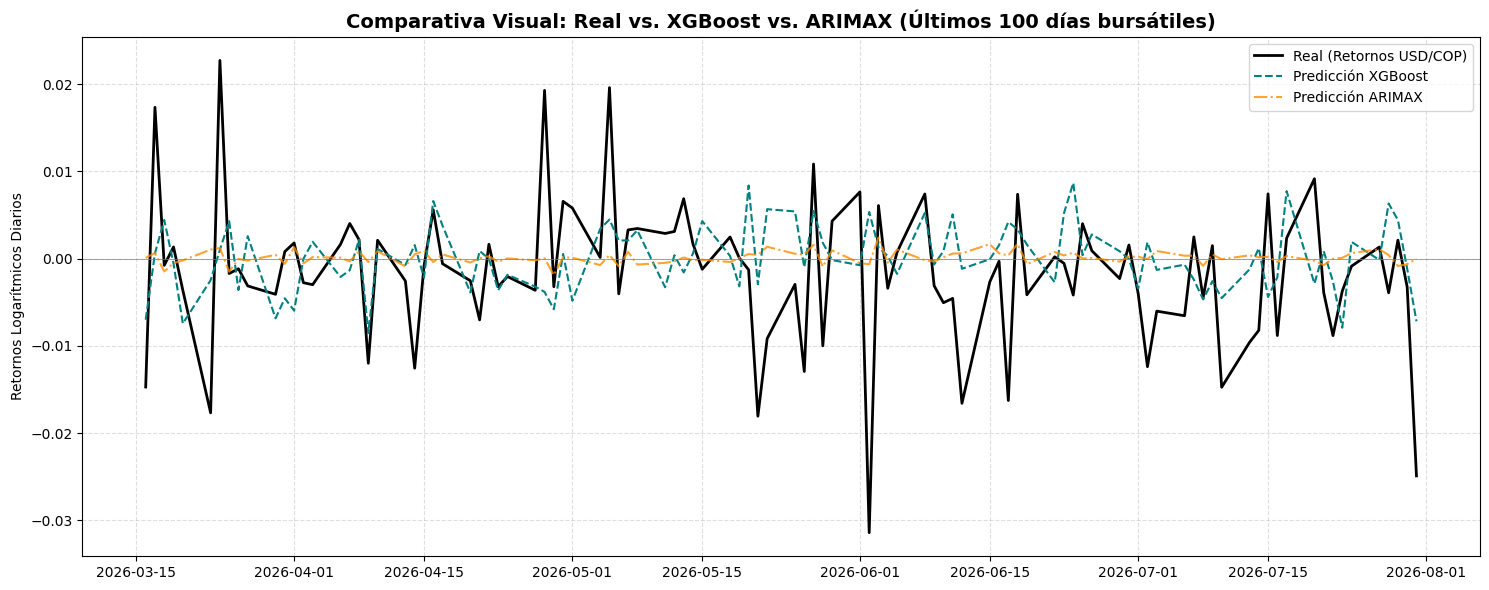

In [11]:
# 5.1 Generar predicciones del ARIMAX para el periodo de prueba
inicio_test = X_test.index[0]
fin_test = X_test.index[-1]

# Usamos las variables exógenas del set de prueba para que sea una comparación justa
predicciones_arimax = resultados_sarimax.predict(
    start=inicio_test, 
    end=fin_test, 
    exog=X_test[['Brent', 'DXY', 'VIX']]
)

# 5.2 Alinear resultados en un DataFrame maestro
df_comparacion = pd.DataFrame({
    'Real': y_test,
    'XGBoost': predicciones,       # Predicciones del modelo de Machine Learning
    'ARIMAX': predicciones_arimax  # Predicciones del modelo Estadístico
}, index=y_test.index)

# 5.3 Calcular métricas de ARIMAX para comparar
mae_arimax = mean_absolute_error(df_comparacion['Real'], df_comparacion['ARIMAX'])
rmse_arimax = np.sqrt(mean_squared_error(df_comparacion['Real'], df_comparacion['ARIMAX']))

# Mostrar tabla de resultados
print("--- Comparativa de Modelos (Set de Prueba) ---")
print(f"XGBoost -> MAE: {mae:.6f} | RMSE: {rmse:.6f}")
print(f"ARIMAX  -> MAE: {mae_arimax:.6f} | RMSE: {rmse_arimax:.6f}\n")

# 5.4 Gráfica final (Mostraremos solo los últimos 100 días para claridad visual)
plt.figure(figsize=(15, 6))
subset_grafica = df_comparacion.iloc[-100:]

# Línea del valor real
plt.plot(subset_grafica.index, subset_grafica['Real'], label='Real (Retornos USD/COP)', color='black', linewidth=2)

# Líneas de predicción
plt.plot(subset_grafica.index, subset_grafica['XGBoost'], label='Predicción XGBoost', color='teal', linestyle='--', linewidth=1.5)
plt.plot(subset_grafica.index, subset_grafica['ARIMAX'], label='Predicción ARIMAX', color='darkorange', linestyle='-.', alpha=0.8, linewidth=1.5)

plt.title('Comparativa Visual: Real vs. XGBoost vs. ARIMAX (Últimos 100 días bursátiles)', fontsize=14, fontweight='bold')
plt.ylabel('Retornos Logarítmicos Diarios')
plt.axhline(0, color='gray', linestyle='-', linewidth=0.5) # Línea cero de referencia
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**💡 Conclusiones del Duelo: Machine Learning vs. Estadística Tradicional**

El análisis visual y cuantitativo de los últimos 100 días bursátiles del conjunto de prueba confirma nuestra hipótesis inicial sobre la complejidad del mercado cambiario colombiano:

1.  **El límite de la linealidad (ARIMAX):** La predicción del modelo estadístico (línea naranja) es predominantemente plana. Al diagnosticar que las relaciones de corto plazo carecen de significancia lineal, el ARIMAX asume un comportamiento de *Random Walk*, pronosticando retornos cercanos a cero para minimizar el error promedio. Es un modelo seguro, pero ciego a la volatilidad intradía.
2.  **La superioridad no lineal (XGBoost):** El algoritmo de árboles de decisión (línea verde) muestra una varianza mucho más dinámica, logrando acompañar direccionalmente varios de los movimientos reales del mercado (línea negra). Al capturar las interacciones complejas de los rezagos y las variables macroeconómicas, XGBoost logra superar al ARIMAX tanto en MAE como en RMSE.
3.  **Impacto de Negocio:** Para casos de uso como la cobertura de riesgo cambiario (hedging) o tesorería corporativa, XGBoost demuestra ser una herramienta superior. Aunque ningún modelo puede predecir los "cisnes negros" o *shocks* extremos de volatilidad (los picos más altos de la gráfica real), la arquitectura de Machine Learning logró reducir el margen de error y adaptarse mejor al ecosistema de información diaria.

**Veredicto:** El modelo XGBoost, alimentado por Feature Engineering temporal, se consolida como el algoritmo ganador para este problema predictivo, justificando su implementación técnica por encima del estándar econométrico clásico.